In [1]:
import json
import os
import pickle
import sys

import httpx
import matplotlib.pyplot as plt
import pandas as pd
import requests
import yaml
from dotenv import load_dotenv
from tqdm import tqdm


# Determine the project root directory for relative imports
try:
    # This will work in scripts where __file__ is defined
    current_dir = os.path.dirname(os.path.abspath(__file__))
    # Assuming "src" is parallel to the script folder
    project_root = os.path.abspath(os.path.join(current_dir, ".."))
except NameError:
    # In notebooks __file__ is not defined: assume we're in notebooks/riziv_dataset/
    project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

In [2]:
###############
# Load data
###############

# Define the path to the BSARD dataset files
BSARD_data_path = os.path.join(project_root, "data", "BSARD_dataset")

# BSARD main table
bsard_corpus_lean = pd.read_csv(os.path.join(BSARD_data_path, 'intermediate', "bsard_corpus_lean_V2.csv"))
bsard_corpus_lean.drop(["Unnamed: 0"], inplace=True, axis=1)

# Keywords dict
keywords_dict_path = os.path.join(BSARD_data_path, 'intermediate', 'keyword_extraction.pkl')
with open(keywords_dict_path, 'rb') as f:
        keywords_dict = pickle.load(f)

###############
# Parse retrieved keyword-related content and build dataframe
###############

# Keep only those articles which have been already scanned
keywords_dict_filter = {k:v for k,v in keywords_dict.items() if v != None} 

parsed_key_terms = []

for art in keywords_dict_filter.keys():

    for n in ["1", "2", "3", "4"]:

        parsed_key_terms.append((art, keywords_dict_filter[art][f"key_concept_{n}"]))

# Build Dataframe
key_terms_df = pd.DataFrame(parsed_key_terms, columns=['article_code', 'key_term'])

In [3]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() > 1].head(25)

key_term
AWIPH                          261
Gouvernement                   140
Code décrétal                  135
assemblée générale             128
procès-verbal                  121
analyse des risques            116
procureur du Roi               113
collège communal               111
tribunal de la famille         110
demande d'agrément             103
amende administrative           97
personnes handicapées           95
agrément                        94
procureur général               93
juge de paix                    91
Agence                          89
pouvoir organisateur            87
ministère public                86
règlement d'ordre intérieur     83
autorité compétente             82
enquête publique                79
organe d'administration         77
prescription                    77
permis d'urbanisme              73
nullité                         68
Name: count, dtype: int64

In [4]:
# List of key terms identified at least twice during scanning

key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() > 1].value_counts()

count
2      5869
3      2129
4      1122
5       657
6       442
       ... 
60        1
57        1
56        1
51        1
261       1
Name: count, Length: 86, dtype: int64

In [5]:
# Total number of hits for key terms identified at least twice

key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() > 1].sum()


53627

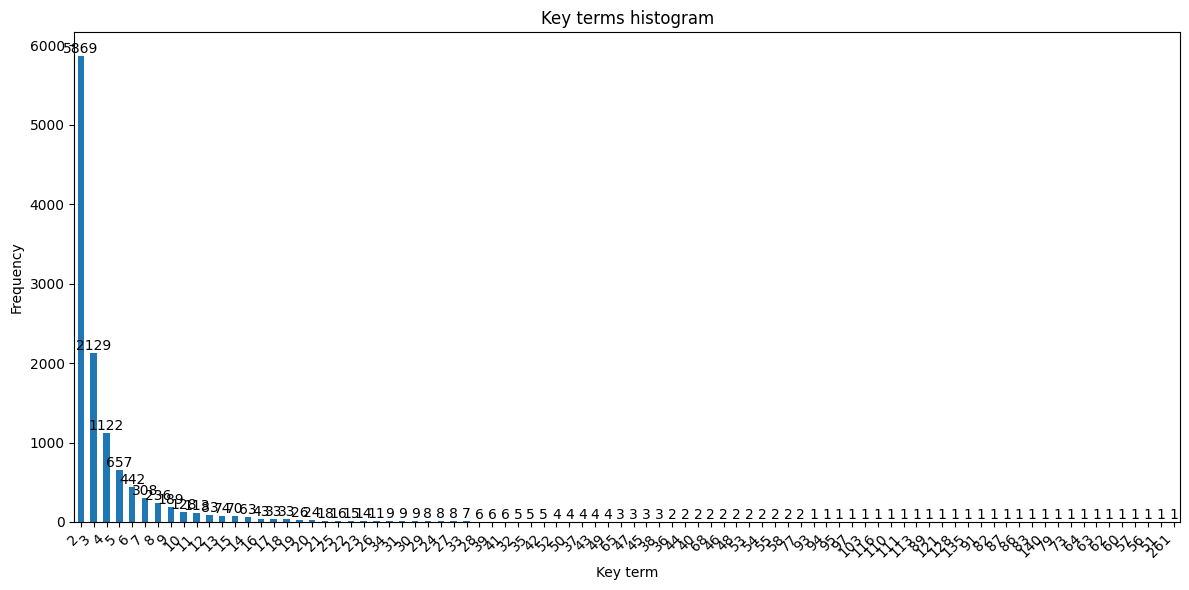

In [6]:
s = key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() > 1].value_counts()

ax = s.plot(kind='bar', figsize=(12, 6))

# Tags
for bar in ax.patches:
    heigth = int(bar.get_height())
    ax.annotate(
        str(heigth),                       # number of hits
        (bar.get_x() + bar.get_width()/2, heigth),  # position (center heigth)
        ha='center', va='bottom'          # alignment (horizontal - vertical)
    )

plt.xticks(rotation=45, ha='right')
plt.xlabel('Key term')
plt.ylabel('Frequency')
plt.title('Key terms histogram')
plt.tight_layout()
plt.show()


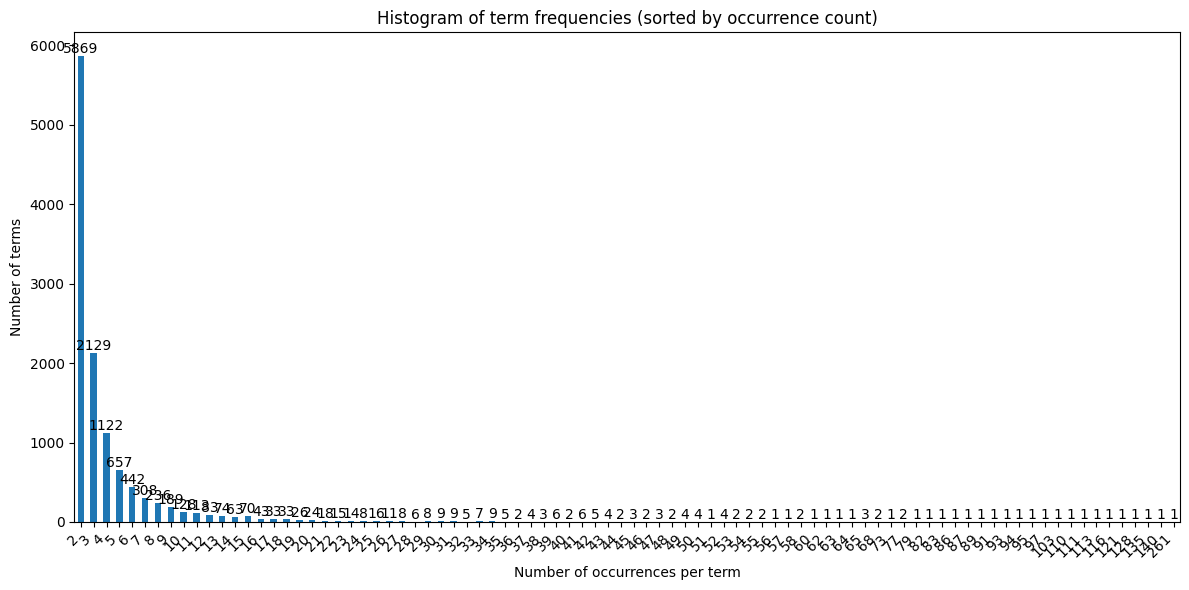

In [7]:
# 1) Count how many times each term appears
term_counts = key_terms_df["key_term"].value_counts()

# 2) Keep only the terms that appear more than once
filtered_counts = term_counts[term_counts > 1]

# 3) Build a “histogram” of those counts: 
#    i.e. how many terms have frequency 2, 3, 4, etc.
frequency_counts = filtered_counts.value_counts()

# 4) Sort by the frequency value (the index) so x-axis goes 2, 3, 4, …
frequency_counts = frequency_counts.sort_index()

# 5) Plot the bar chart
fig, ax = plt.subplots(figsize=(12, 6))
frequency_counts.plot(kind='bar', ax=ax)

# 6) Annotate each bar with its height
for bar in ax.patches:
    height = int(bar.get_height())
    ax.annotate(
        str(height),                              # show the count on top
        (bar.get_x() + bar.get_width() / 2, height),  # position: center top of each bar
        ha='center', va='bottom'
    )

# 7) Tidy up labels and title
ax.set_xticklabels(frequency_counts.index, rotation=45, ha='right')
ax.set_xlabel('Number of occurrences per term')
ax.set_ylabel('Number of terms')
ax.set_title('Histogram of term frequencies (sorted by occurrence count)')
plt.tight_layout()
plt.show()


In [8]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() > 1].sample(15) 

key_term
comptabilité générale             2
monnaies contrefaites             3
gestion du personnel              4
composition du ménage             2
non à ordre                       2
langues nationales                3
Collège d'urbanisme               4
Données à caractère personnel    14
documents d'information           3
stagiaire judiciaire              2
Délai de recours                  3
délai ordinaire des citations     2
prix convenu                      2
agréé                             6
subside                          11
Name: count, dtype: int64

In [9]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 10].head(25)

key_term
Permis d'urbanisme                                          10
aspects psychosociaux                                       10
demande incomplète                                          10
inscription                                                 10
Code forestier                                              10
suspension du permis                                        10
ordre de paiement                                           10
majorité absolue                                            10
forme légale                                                10
médecine préventive                                         10
maison d'accueil                                            10
date certaine à l'envoi                                     10
contrevenant                                                10
accord de réparation collective                             10
compensation                                                10
servitude                                     

In [10]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 9].head(25)

key_term
citation à comparaître               9
charge de la preuve                  9
fondation                            9
dispositions du présent titre        9
exploitation agricole                9
servitudes                           9
juge délégué                         9
notification du jugement             9
pouvoir public                       9
titulaire de droits réels            9
cassation                            9
administration de l'environnement    9
tribunaux correctionnels             9
dossier de la procédure              9
juges                                9
comptes consolidés                   9
sûretés sur navires                  9
incapacité d'exprimer sa volonté     9
mandat d'arrêt                       9
plan d'actions environnementales     9
SIGeC                                9
entreprise de travail adapté         9
délai d'un an                        9
accompagnement personnalisé          9
loi hypothécaire                     9
Name: count, dty

In [11]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 8].sample(25)

key_term
Code de l'Eau                           8
garanties financières                   8
opérateur immobilier                    8
centres de planning familial            8
Comité stratégique                      8
créanciers hypothécaire                 8
Bien-être des travailleurs              8
communication électronique              8
disposition statutaire contraire        8
application des peines                  8
intégration des personnes étrangères    8
frais                                   8
évaluation participative                8
délai imparti                           8
cours d'appel                           8
Médiateur de dettes                     8
conditions prévues                      8
valeurs limites                         8
autorisation de mise sur le marché      8
sentence arbitrale                      8
établissement                           8
présent code                            8
fusion des communes                     8
Droit de préemption      

In [12]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 7].head(25)

key_term
obligations nominatives              7
dossiers de santé                    7
dissolution judiciaire               7
avis défavorables                    7
Comité d'accompagnement              7
séparation de biens                  7
retrait de la reconnaissance         7
fédération                           7
Propriétaire du navire               7
biens                                7
séance publique                      7
personnel contractuel                7
soins palliatifs                     7
prestation de serment                7
personnes morales de droit public    7
procédure d'adoption                 7
données anonymes                     7
obligations convertibles             7
suspension des droits électoraux     7
compétence des juridictions          7
remboursement                        7
pouvoirs de l'assemblée générale     7
police judiciaire                    7
désignation des membres              7
rapport spécial                      7
Name: count, dty

In [13]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 6].head(25)

key_term
contrôleur des engagements         6
droit exclusif                     6
suspicion légitime                 6
taux débiteur                      6
navire belge                       6
titre                              6
débiteurs solidaire                6
licences multiterritoriales        6
effets mobiliers                   6
milieu hyperbare                   6
grade                              6
consentement préalable             6
exploitant                         6
procès-verbal de saisie            6
décision d'octroi                  6
Mesures de prévention              6
droits fondamentaux                6
registre central successoral       6
vérification des conditions        6
contrôle financier                 6
détention                          6
législation sur la comptabilité    6
droit commun                       6
pièces de comparaison              6
subventions annuelles              6
Name: count, dtype: int64

In [14]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 5].head(25)

key_term
action en rescision                            5
participation du public                        5
prime de fin d'année                           5
commission consultative spéciale               5
conseil de discipline                          5
partie décrétale                               5
fonctionnaire dirigeant                        5
plaintes                                       5
accord tripartite                              5
Autorité des services et marchés financiers    5
cessation des fonctions                        5
modifications                                  5
levée de la suspension                         5
rang A3 ou A4                                  5
déclaration préalable                          5
aliments                                       5
faute                                          5
nullité de plein droit                         5
convention d'accueil                           5
modalités d'exercice                           5
zones vulné

In [15]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 4].sample(25)

key_term
sanction de niveau 5                   4
exclusion des droits électoraux        4
résiliation du bail                    4
Code de la nationalité belge           4
conseiller en environnement            4
conseillers suppléants                 4
insertion socio-professionnelle        4
transcription                          4
cession de biens                       4
suffrages nominatifs                   4
approbation du Ministre                4
Ordre des barreaux                     4
prédiagostic                           4
Responsabilité civile                  4
émission d'obligations                 4
sécurité des données                   4
réseau public de distribution d'eau    4
actions en justice                     4
bail à ferme                           4
gestion                                4
personnes étrangères                   4
membre du personnel délégué            4
engagements                            4
patrimoine                             4
prêt à 

In [16]:
key_terms_df["key_term"].value_counts()[key_terms_df["key_term"].value_counts() == 3].sample(25)

key_term
Organe central                              3
Acceptation pure et simple                  3
emphytéose                                  3
Code de droit economique                    3
respect des obligations                     3
ligne directe                               3
Commission des licences obligatoires        3
article 275                                 3
prononcé                                    3
Bien-être animal                            3
autorités administratives                   3
Parlements de région                        3
indemnité de poste                          3
dossier au greffe                           3
préavis de six mois                         3
garde forestier                             3
société de logement                         3
fonction dirigeante locale                  3
condamnations prononcées                    3
procédure de récusation                     3
bandes                                      3
unanimité                

In [17]:
len(key_terms_df[key_terms_df["key_term"] == "Société wallonne du Logement"]["article_code"].str.split(".").str[0].unique())

1

In [23]:
# Cuantas leyes distintas estan relacionadas en promedio con un key term?

# Falta aqui filtrar por longitud para eliminar los unos o ir solo a por conteos determinados

set_key_terms = set(key_terms_df["key_term"])

unique_acts = {}

for key_term in set_key_terms: # iterar por todos los key terms
    tmp_df = key_terms_df[key_terms_df["key_term"] == key_term] # DF filtrado para solo un key term
    uniq_acts_term = len(tmp_df["article_code"].str.split(".").str[0].unique()) # Numero de leyes distintas involucradas en un key term
    #print(key_term, uniq_acts_term)
    unique_acts[key_term]=uniq_acts_term

In [24]:
unique_acts_df = pd.DataFrame(unique_acts.items(), columns=['key_term', 'unique_acts'])

In [26]:
unique_acts_df["unique_acts"].value_counts().sort_index()

unique_acts
1     43378
2      3462
3       977
4       390
5       217
6       129
7        75
8        39
9        24
10       18
11        9
12       16
13       10
14        5
15        3
16        4
17        3
18        1
19        1
20        1
21        1
Name: count, dtype: int64